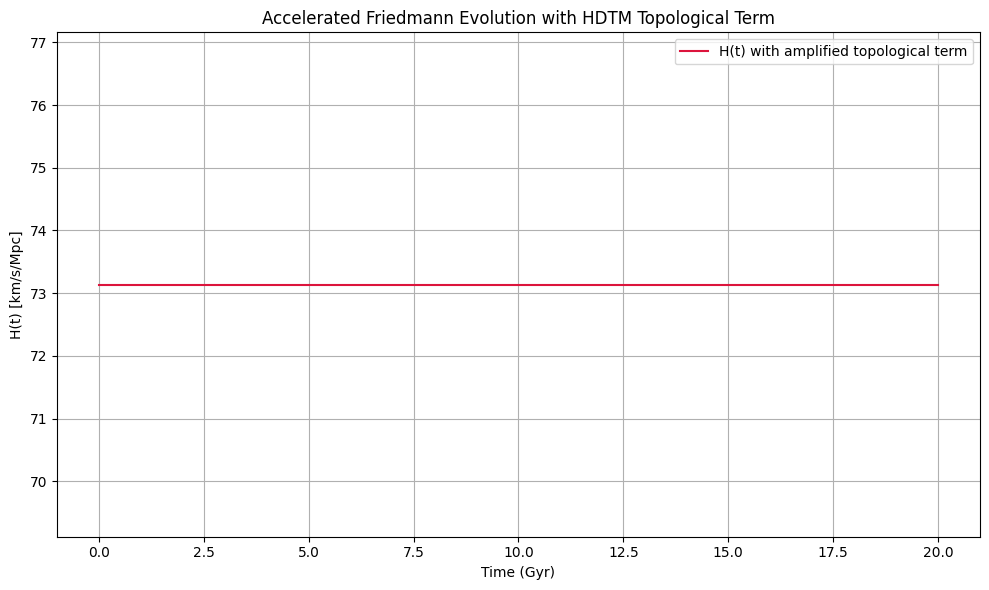

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Amplified topological parameters
G0 = 6.67430e-11
Lambda = 1.1e-52
lambda_phi1 = 1e-14  # stronger topological coupling
Lambda_T = 1e14
rho0 = 1e-26

def friedmann(t, y):
    H = y[0]
    rho = rho0 * (1 + t)**-3
    dHdt = -0.5 * H**2 + (lambda_phi1 * H**3) / Lambda_T
    return [dHdt]

t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)
H0 = 2.27e-18 + 1e-19

sol = solve_ivp(friedmann, t_span, [H0], t_eval=t_eval)
H_kmsmpc = sol.y[0] * 3.086e19

plt.figure(figsize=(10, 6))
plt.plot(sol.t, H_kmsmpc, label='H(t) with amplified topological term', color='crimson')
plt.xlabel('Time (Gyr)')
plt.ylabel('H(t) [km/s/Mpc]')
plt.title('Accelerated Friedmann Evolution with HDTM Topological Term')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()